# WaveSlide - Model Training

### Collaborators:
- Raul Andres Cerreño Zeballos
- Leicy Cristel Cahuana Lopez
- Diego Fabrizio Mucha Alvarez

## 1. Introduction

The notebook includes the training of our model based on fine tuning MobileNetV3-Small. To train the model, we will use the processed data we made on the EDA_final notebook.

**This notebook covers stages 4 and 5 of the CRISP-DM methodology: Modelling and Evaluation.**

In [ ]:
# Import Libraries
from pathlib import Path
import json
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras import layers, mixed_precision, models
mixed_precision.set_global_policy("float32")
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

In [ ]:
# Check for GPU
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Loading the Processed Data

### 2.1. Data structure
The processed data has the following structure

```text
processed/
    call/
        image_1.jpg
    fist/
        image_2.jpg
    like/
        image_3.jpg
    two_up/
        image_4.jpg
    unknown/
        image_5.jpg
```

Each folder with each image class

### 2.2. Loading the data info into a Dataframe

Mount google drive on colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# this so colab loads the images into the colab path and works faster
!cp -r /content/drive/MyDrive/processed /content/processed
PROCESSED_DATA_ROOT = Path("/content/processed")

In [ ]:
def build_mobilenet_dataframe_from_folder(crops_root):
    rows = []
    crops_root = Path(crops_root)

    for label_dir in sorted(crops_root.iterdir()):
        if label_dir.name == "call":
            label_id = 0
        elif label_dir.name == "fist":
            label_id = 1
        elif label_dir.name == "like":
            label_id = 2
        elif label_dir.name == "two_up":
            label_id = 3
        elif label_dir.name == "unknown":
            label_id = 4
        label = label_dir.name

        for image_path in sorted(label_dir.rglob("*.jpg")):
            rows.append({
                "image_path": str(image_path),
                "label": label,
                "label_id": label_id
            })

    return pd.DataFrame(rows)


df_processed = build_mobilenet_dataframe_from_folder(PROCESSED_DATA_ROOT)

print(f"Using uploaded crops from: {PROCESSED_DATA_ROOT}")
print(f"Readable crop images: {len(df_processed)}")
print(df_processed["label"].value_counts())

Using uploaded crops from: /content/processed
Readable crop images: 27659
label
two_up     5875
call       5618
unknown    5532
fist       5515
like       5119
Name: count, dtype: int64


Checking the dataframe

In [ ]:
df_processed.head()

,image_path,label,label_id
0,/content/processed/call/00005c9c-3548-4a8f-9d0...,call,0
1,/content/processed/call/000fa617-c7ba-47f9-986...,call,0
2,/content/processed/call/0019ae8e-82b3-4438-882...,call,0
3,/content/processed/call/0020a3db-82d8-47aa-864...,call,0
4,/content/processed/call/002ab802-bb62-41ff-b42...,call,0


### 2.3. Divide images in train and test
We will divide the full dataset in 80% train, 20% Test, and the test set into 10% test and 10% validation

In [ ]:
train_df, other_df = train_test_split(
    df_processed,
    test_size=0.20,
    random_state=42,
    stratify=df_processed["label_id"],
)

val_df, test_df = train_test_split(
    other_df,
    test_size=0.50,
    random_state=42,
    stratify=other_df["label_id"]
)

print(f"Images in train_df: {len(train_df)}")
print(f"Distribution in train_df: {train_df["label"].value_counts()}")
print(f"Images in val_df: {len(val_df)}")
print(f"Distribution in val_df: {val_df["label"].value_counts()}")
print(f"Images in test_df: {len(test_df)}")
print(f"Distribution in val_df: {val_df["label"].value_counts()}")

Images in train_df: 22127
Distribution in train_df: label
two_up     4700
call       4494
unknown    4426
fist       4412
like       4095
Name: count, dtype: int64
Images in val_df: 2766
Distribution in val_df: label
two_up     588
call       562
unknown    553
fist       551
like       512
Name: count, dtype: int64
Images in test_df: 2766
Distribution in val_df: label
two_up     588
call       562
unknown    553
fist       551
like       512
Name: count, dtype: int64


### 2.4. Load dataset into tensorflow
Now we load the images directly into tensorflow using the paths on our dataset to get ready to train the model

In [ ]:
# Parameters for data loading
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE # improve performance: when model is training on one batch, TF prepares the next batch in background
IMG_SIZE = 224
NUM_CLASSES = 5

In [ ]:
# Function to load a image into tensorflow
def load_image_tf(image_path, label_id):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.cast(image, tf.float32)
    return image, label_id

# Function to create the tf dataset with the images loaded
def make_dataset_tf(df, training=False):
    paths = df["image_path"].astype(str).to_numpy()
    labels = df["label_id"].astype("int32").to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(load_image_tf, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Creating the datasets
train_ds = make_dataset_tf(train_df)
val_ds = make_dataset_tf(val_df)
test_ds = make_dataset_tf(test_df)

## 3. Train the model
Now that we ahve our data loaded, we are ready to train the model

### 3.1. Create the model

In [ ]:
# MODEL HYPRPARAMETERS

# For data augmetnation
RANDOM_ROTATION=0.05
RANDOM_ZOOM=0.10
RANDOM_CONTRAST=0.10

# For training
LEARNING_RATE=1e-3
EPOCHS=30
EARLY_STOPPING_PATIENCE=5

# For fine tuning
UNFROZEN_LAYERS=30

Our base model will be MobileNetV3Small as we said before, and for this part we will do transfer learning and then do fine tuning next

In [ ]:
# We will include data augmentation for the image
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, # Takes away the head (final or output layer) since mn was originally trained on 1000 classes of imagenet
    weights="imagenet",
    include_preprocessing=False,
)
base_model.trainable = False # For now, we only will train the final layer (head), so for now its transfer learning

# Adding our own input layer, and creating the final model architecture
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x) # To normalize the intensities of the ipxels on image to -1/1
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x) # Dropout some features to prevent overfitting
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

# See how our model is
model = models.Model(inputs, outputs)
model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         2,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,005 (3.59 MB)

 Trainable params: 2,885 (11.27 KB)

 Non-trainable params: 939,120 (3.58 MB)

### 3.2. Training the head layer of the model
We will do now transfer learning using MobileNetV3Small pretrained on ImageNet first

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping_head = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping_head],
)

Epoch 1/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.8516 - loss: 0.4551 - val_accuracy: 0.9324 - val_loss: 0.2384
Epoch 2/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.9382 - loss: 0.1997 - val_accuracy: 0.9407 - val_loss: 0.1802
Epoch 3/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.9479 - loss: 0.1625 - val_accuracy: 0.9584 - val_loss: 0.1410
Epoch 4/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9509 - loss: 0.1457 - val_accuracy: 0.9530 - val_loss: 0.1370
Epoch 5/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9558 - loss: 0.1353 - val_accuracy: 0.9563 - val_loss: 0.1249
Epoch 6/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9570 - loss: 0.1288 - val_accuracy: 0.9649 - val_loss: 0.1079
Epoch 7/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9571 - loss: 0.1232 - val_accuracy: 0.9534 - val_loss: 0.1280
Epoch 8/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9593 - loss: 0.1190 - 

### 3.3. Viewing initial results

Plotting Accuracy History over epochs

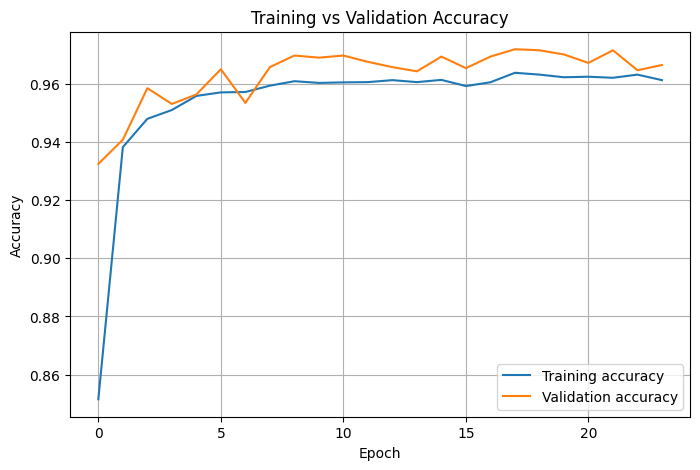

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_head.history["accuracy"], label="Training accuracy")
plt.plot(history_head.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Plotting loss function history over epochs

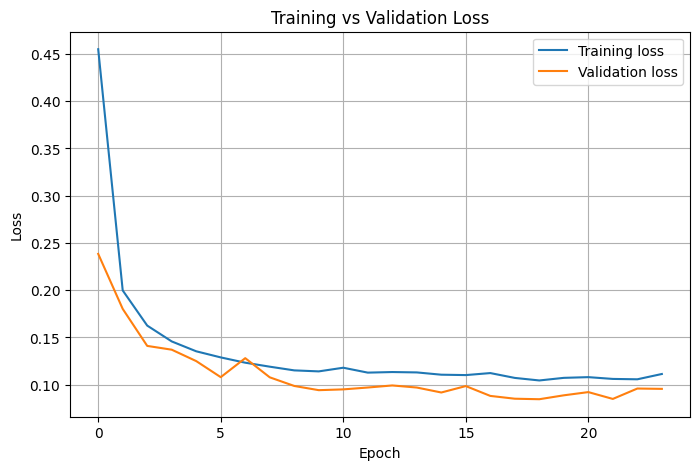

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_head.history["loss"], label="Training loss")
plt.plot(history_head.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Final validation accuracy after intial training

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9714 - loss: 0.0846
Validation loss: 0.0846
Validation accuracy: 0.9714


Confusion matrix after initial training on validation dataset

<Figure size 800x800 with 0 Axes>

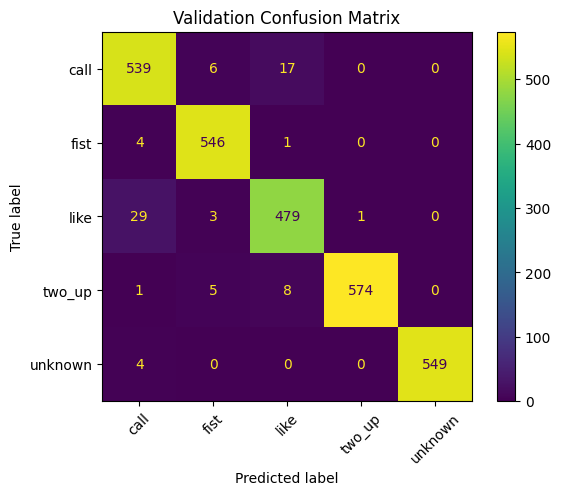

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["call", "fist", "like", "two_up", "unknown"]
)

plt.figure(figsize=(8, 8))
disp.plot(cmap=None, xticks_rotation=45)
plt.title("Validation Confusion Matrix")
plt.show()

### 3.4. Training more layers of the model - Fine Tuning
Now that we did the transfer learning, we will try fine tuning by unfreezing more layers of our model, meaning we will modify some weights of MobileNetV3 directly

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-UNFROZEN_LAYERS]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping_finetune = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping_finetune],
)

Epoch 1/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.9832 - loss: 0.0488 - val_accuracy: 0.9877 - val_loss: 0.0473
Epoch 2/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9945 - loss: 0.0158 - val_accuracy: 0.9913 - val_loss: 0.0414
Epoch 3/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9962 - loss: 0.0108 - val_accuracy: 0.9920 - val_loss: 0.0331
Epoch 4/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9976 - loss: 0.0078 - val_accuracy: 0.9917 - val_loss: 0.0315
Epoch 5/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.9977 - loss: 0.0061 - val_accuracy: 0.9953 - val_loss: 0.0179
Epoch 6/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9983 - loss: 0.0057 - val_accuracy: 0.9942 - val_loss: 0.0285
Epoch 7/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.9986 - loss: 0.0051 - val_accuracy: 0.9942 - val_loss: 0.0245
Epoch 8/30
346/346 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.9987 - loss: 0.0041 - 

### 3.5. Viewing fine tuning

Plotting Accuracy History over epochs

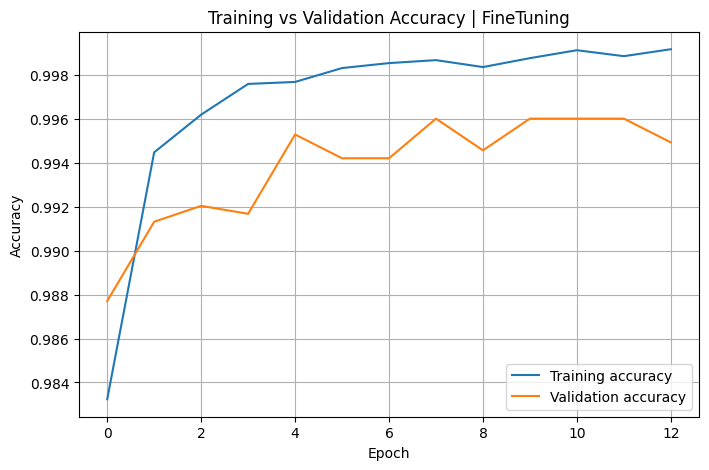

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_finetune.history["accuracy"], label="Training accuracy")
plt.plot(history_finetune.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy | FineTuning")
plt.legend()
plt.grid(True)
plt.show()

Plotting loss function history over epochs

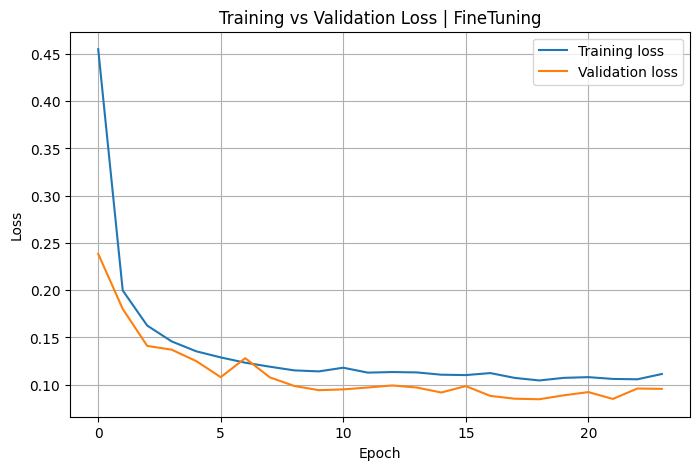

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_head.history["loss"], label="Training loss")
plt.plot(history_head.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss | FineTuning")
plt.legend()
plt.grid(True)
plt.show()

Final validation accuracy after intial training

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9960 - loss: 0.0152
Validation loss: 0.0152
Validation accuracy: 0.9960


Confusion matrix after initial training on validation dataset

<Figure size 800x800 with 0 Axes>

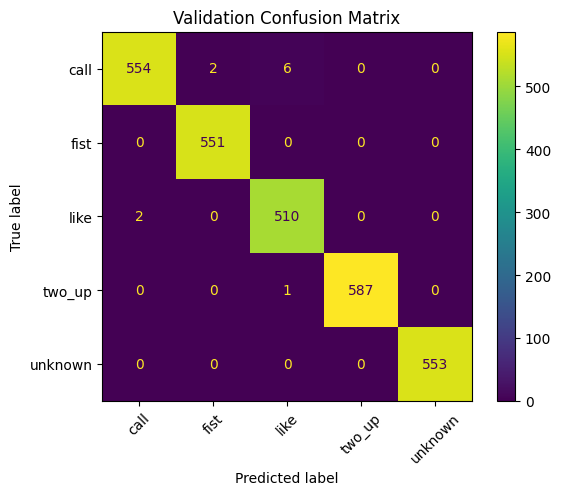

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["call", "fist", "like", "two_up", "unknown"]
)

plt.figure(figsize=(8, 8))
disp.plot(cmap=None, xticks_rotation=45)
plt.title("Validation Confusion Matrix")
plt.show()

## 4. Testing of the model
Now that we have the model trained, we will test it with the test dataset

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Testing loss: {test_loss:.4f}")
print(f"Testing accuracy: {test_accuracy:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9967 - loss: 0.0197
Testing loss: 0.0197
Testing accuracy: 0.9967


Confusion matrix after final testing

<Figure size 800x800 with 0 Axes>

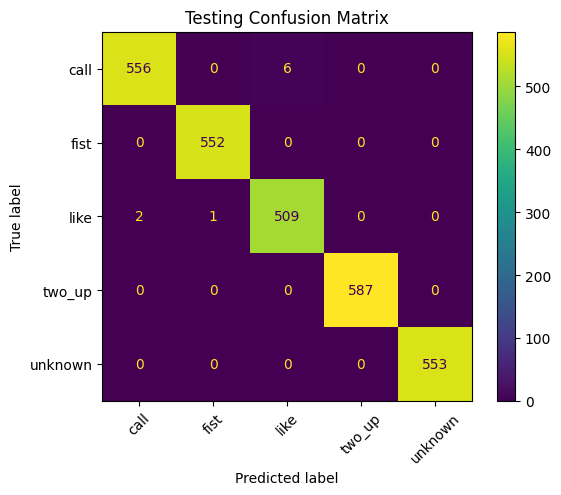

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["call", "fist", "like", "two_up", "unknown"]
)

plt.figure(figsize=(8, 8))
disp.plot(cmap=None, xticks_rotation=45)
plt.title("Testing Confusion Matrix")
plt.show()

Additional Metrics

In [ ]:
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1-score:", f1_macro)

Macro Precision: 0.9965913933816821
Macro Recall: 0.9966928936832741
Macro F1-score: 0.9966377553942707


## 5. Conclusions

After finishing the testing of our model, we have the following conclusions.

- The model had an excelent performance, this was expected since we are based on MobileNetV3Small, a recent SOTA model. We got 0.995~ on Macro F1-scoe, 0.995~ on Accuracy in the final testing set.

- The model did not overfit or underfit, since the metrics are really similar in the training, validation and testing dataset.

---

## 6. Exporting the model
Now that we have the model, we can export as a .tflite to use on the project

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("WaveSlideV1.tflite", "wb") as f:
    f.write(tflite_model)

print("Model create succesfully")

Saved artifact at '/tmp/tmpwxr41v1v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_174')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136575909628816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909630928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909630736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909629584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909631504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909630352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909632656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909632464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909630544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136575909631696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1365759096